# Khởi tạo môi trường và Tải dữ liệu

In [ ]:
! pip install pyspark
! pip install kagglehub
import kagglehub
import os

print("Đang tải dữ liệu từ Kaggle về Google Colab...")
dataset_path = kagglehub.dataset_download("robertocarlost/fmcg-multi-country-sales-dataset")

#lấy đường dẫn CSV
csv_file_path = os.path.join(dataset_path, "fmcg_sales_3years_1M_rows.csv")
print(f"Dữ liệu đã được tải xong và lưu tại: {csv_file_path}")

Đang tải dữ liệu từ Kaggle về Google Colab...
Using Colab cache for faster access to the 'fmcg-multi-country-sales-dataset' dataset.
Dữ liệu đã được tải xong và lưu tại: /kaggle/input/fmcg-multi-country-sales-dataset/fmcg_sales_3years_1M_rows.csv


# Khởi tạo Spark & Đọc dữ liệu

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Khởi tạo Spark Session với cấu hình tối ưu cho tập dữ liệu
spark = SparkSession.builder \
    .appName("FMCG_Demand_Forecasting_Inventory") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "4g") \
    .getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "UTC")

print("Spark Version: ", spark.version)

# Đọc dữ liệu từ biến csv_file_path
raw_df = spark.read.csv(csv_file_path, header=True, inferSchema = True)

print(f"Tổng số dòng dữ liệu ban đầu: {raw_df.count()}")

Spark Version:  4.0.2
Tổng số dòng dữ liệu ban đầu: 1100000


# Khám phá dữ liệu (EDA) & Phân tích ABC/XYZ

In [ ]:
print("ĐANG THỰC HIỆN PHÂN TÍCH EDA & ABC/XYZ...")

# Chuẩn bị dữ liệu cho EDA
eda_df = raw_df.withColumn("Date", F.to_date("date")) \
               .withColumn("Revenue", F.col("units_sold") * F.col("list_price"))

# 1. Phân tích ABC (Dựa trên tỷ trọng doanh thu theo quốc gia)
window_spec = Window.partitionBy("country").orderBy(F.desc("Regional_Revenue"))
abc_analysis = eda_df.groupby("country", "sku_id") \
    .agg(F.sum("Revenue").alias("Regional_Revenue")) \
    .withColumn("Total_Country_Rev", F.sum("Regional_Revenue").over(Window.partitionBy("country"))) \
    .withColumn("Cum_Rev_Pct", F.sum("Regional_Revenue").over(window_spec) / F.col("Total_Country_Rev")) \
    .withColumn("ABC_Class",
        F.when(F.col("Cum_Rev_Pct") <= 0.7, "A")
        .when(F.col("Cum_Rev_Pct") <= 0.9, "B")
        .otherwise("C"))

print("--- Kết quả Phân tích ABC (Sản phẩm chủ lực) ---")
abc_analysis.select("country", "sku_id", "Cum_Rev_Pct", "ABC_Class") \
.orderBy("country", F.asc("Cum_Rev_Pct")).show(10)

# 2. Phân tích XYZ (Dựa trên độ biến động nhu cầu - Hệ số CV)
xyz_analysis = eda_df.groupby("sku_id") \
    .agg(F.avg("units_sold").alias("Avg_Qty"), F.stddev("units_sold").alias("Std_Qty")) \
    .withColumn("CV", F.when(F.col("Avg_Qty") != 0, F.col("Std_Qty") / F.col("Avg_Qty")).otherwise(0)) \
    .withColumn("XYZ_Class",
        F.when(F.col("CV") <= 0.5, "X") # Biến động thấp
        .when(F.col("CV") <= 1.0, "Y") # Biến động trung bình
        .otherwise("Z"))               # Biến động cao

print("--- Kết quả Phân tích XYZ (Độ biến động rủi ro) ---")
xyz_analysis.select("sku_id", "CV", "XYZ_Class").orderBy(F.asc("CV")).show(10)

# 3. Phân tích Tương quan (Độ co giãn của giá & Khuyến mãi) - Mục 5.3
print("--- Hệ số tương quan (Giá & Khuyến mãi vs Số lượng bán) ---")
correlation_data = eda_df.select(
    F.corr("list_price", "units_sold").alias("Price_Volume_Corr"),
    F.corr("discount_pct", "units_sold").alias("Discount_Volume_Corr")
)
correlation_data.show()

# 4. Phân tích Mùa vụ (Xu hướng bán hàng theo tháng) - Mục 5.1
print("--- Phân tích Mùa vụ (Tổng lượng bán theo tháng) ---")
if "month" not in eda_df.columns:
    eda_df = eda_df.withColumn("month", F.month(F.col("date")))

seasonality_month = eda_df.groupby("month").agg(F.sum("units_sold").alias("Monthly_Volume")).orderBy("month")
seasonality_month.show()

ĐANG THỰC HIỆN PHÂN TÍCH EDA & ABC/XYZ...
--- Kết quả Phân tích ABC (Sản phẩm chủ lực) ---
+-------+-------+--------------------+---------+
|country| sku_id|         Cum_Rev_Pct|ABC_Class|
+-------+-------+--------------------+---------+
|Austria|SKU0027|0.045394419107268255|        A|
|Austria|SKU0018| 0.08380125690628343|        A|
|Austria|SKU0092| 0.11974331922197441|        A|
|Austria|SKU0099| 0.15388190852528474|        A|
|Austria|SKU0057|  0.1867865146311013|        A|
|Austria|SKU0061| 0.21894875738744912|        A|
|Austria|SKU0100| 0.24984976675152468|        A|
|Austria|SKU0064| 0.28042580881931545|        A|
|Austria|SKU0041| 0.31067586402571074|        A|
|Austria|SKU0028| 0.33695942838716325|        A|
+-------+-------+--------------------+---------+
only showing top 10 rows
--- Kết quả Phân tích XYZ (Độ biến động rủi ro) ---
+-------+-------------------+---------+
| sku_id|                 CV|XYZ_Class|
+-------+-------------------+---------+
|SKU0072|0.364569477066286

# Làm sạch dữ liệu (Data Cleaning)

In [ ]:
print("ĐANG THỰC HIỆN LÀM SẠCH DỮ LIỆU (DATA CLEANING)...")

# Lọc bỏ giá trị rỗng ở các cột quan trọng
required_cols = ["date", "country", "store_id", "sku_id",
                 "units_sold", "list_price", "gross_sales", "net_sales"]
df_clean = raw_df.dropna(subset=required_cols)
df_clean = df_clean.filter(
    F.col("date").isNotNull() &
    (F.length(F.trim("country"))> 0) &
    (F.length(F.trim("store_id")) > 0) &
    (F.length(F.trim("sku_id")) > 0)
)
# Chuẩn hóa dữ liệu chuỗi (Categorical)
df_clean = (
    df_clean
    .withColumn("country", F.upper(F.trim("country")))
    .withColumn("city", F.upper(F.trim("city")))
    .withColumn("channel", F.upper(F.trim("channel")))
    .withColumn("category", F.upper(F.trim("category")))
    .withColumn("subcategory", F.upper(F.trim("subcategory")))
    .withColumn("brand", F.upper(F.trim("brand")))
    .withColumn("sku_id", F.upper(F.trim("sku_id")))
    .withColumn("store_id", F.upper(F.trim("store_id")))
    .withColumn("supplier_id", F.upper(F.trim("supplier_id")))
    .withColumn("sku_name", F.trim("sku_name")) # Tên SKU giữ nguyên hoa/thường, chỉ xóa khoảng trắng
)
# Xử lý ngày tháng & Ép kiểu dữ liệu (Typing Casting)
df_clean = df_clean.withColumn("date", F.to_date(F.col("date")))

numeric_cols = [
    ("units_sold", "double"), ("list_price", "double"),
    ("gross_sales", "double"), ("net_sales", "double"),
    ("discount_pct", "double"), ("promo_flag", "int"),
    ("is_weekend", "int"), ("is_holiday", "int"),
    ("stock_out_flag", "int"), ("margin_pct", "double"),
    ("stock_on_hand", "double"), ("lead_time_days", "double"),
    ("purchase_cost", "double")
]
for col_name, col_type in numeric_cols:
    df_clean = df_clean.withColumn(col_name, F.col(col_name).cast(col_type))

# Áp dụng Business Rules (Ràng buộc logic kinh doanh)
df_clean = df_clean.filter(
    (F.col("units_sold") >= 0) &
    (F.col("list_price") > 0) &
    (F.col("gross_sales") >= 0) &
    (F.col("net_sales") >= 0) &
    (F.col("discount_pct").between(0.0, 1.0)) &
    (F.col("promo_flag").isin(0, 1)) &
    (F.col("is_weekend").isin(0, 1)) &
    (F.col("is_holiday").isin(0, 1)) &
    (F.col("stock_out_flag").isin(0, 1)) &
    (F.col("margin_pct").between(-0.1, 1.0))
)
# Đối soát Doanh thu (Data Integrity)
# Kiểm tra: Lượng bán x Giá niêm yết phải khớp với Tổng doanh thu (cho phép sai số 0.01)
df_clean = df_clean.withColumn("calc_gross", F.col("units_sold") * F.col("list_price"))
df_clean = df_clean.filter(F.abs(F.col("calc_gross") - F.col("gross_sales")) <= F.lit(0.01)).drop("calc_gross")

# Kiểm tra logic Chuỗi cung ứng (Kho bãi)
df_clean = df_clean.filter(
    (F.col("stock_on_hand") >= 0) &
    (F.col("lead_time_days") >= 0) &
    (F.col("purchase_cost") > 0) &
    (F.length(F.trim("supplier_id")) > 0)
)
# Nếu cờ báo hết hàng = 1, tồn kho BẮT BUỘC phải bằng 0
df_clean = df_clean.filter(~((F.col("stock_out_flag") == 1) & (F.col("stock_on_hand") != 0)))

# Xử lý Outlier: Cắt bỏ 1% các giao dịch có số lượng bán cao bất thường (phân vị 99%)
units_p99 = df_clean.approxQuantile("units_sold", [0.99], 0.01)[0]
df_clean = df_clean.filter(F.col("units_sold") <= F.lit(units_p99))

# Khử trùng lặp (Deduplication)
# Nếu có nhiều bản ghi trùng Ngày, Cửa hàng, Sản phẩm, Kênh -> Chỉ giữ 1 bản ghi có doanh thu cao nhất
dedup_window = Window.partitionBy("date", "store_id", "sku_id", "channel") \
                     .orderBy(F.col("net_sales").desc_nulls_last())
df_clean = (
    df_clean
    .withColumn("rn", F.row_number().over(dedup_window))
    .filter(F.col("rn") == 1)
    .drop("rn")
)

# Kết quả
print(f"Số lượng dòng ban đầu (raw_df): {raw_df.count()}")
print(f"Số lượng dòng sau khi làm sạch (df_clean): {df_clean.count()}")
print("-" * 50)

ĐANG THỰC HIỆN LÀM SẠCH DỮ LIỆU (DATA CLEANING)...
Số lượng dòng ban đầu (raw_df): 1100000
Số lượng dòng sau khi làm sạch (df_clean): 1066890
--------------------------------------------------


# Tạo đặc trưng

In [ ]:
# =====================================================================
# CELL 5: FEATURE ENGINEERING
# =====================================================================
print("ĐANG THỰC HIỆN FEATURE ENGINEERING...")

# 1. Thời gian & Chu kỳ
df_feat = df_clean.withColumn("weekday", F.dayofweek("date") - 1) \
                  .withColumn("month", F.month("date")) \
                  .withColumn("is_weekend", F.when(F.dayofweek("date").isin(1, 7), 1).otherwise(0)) \
                  .withColumn("season",
                               F.when(F.month("date").isin(3, 4, 5), 1)
                                .when(F.month("date").isin(6, 7, 8), 2)
                                .when(F.month("date").isin(9, 10, 11), 3)
                                .otherwise(4))

# 2. Giá & Khuyến mãi
df_feat = df_feat.withColumn("discount_amount", F.col("list_price") * F.col("discount_pct")) \
                 .withColumn("final_unit_price", F.col("list_price") * (1 - F.col("discount_pct"))) \
                 .withColumn("log_units_sold", F.log1p("units_sold"))

# 3. Chuỗi thời gian (Window)
w_rolling_7d = Window.partitionBy("sku_id", "store_id").orderBy("date").rowsBetween(-6, 0)
w_lag = Window.partitionBy("sku_id", "store_id").orderBy("date")

df_feat = df_feat.withColumn("rolling_7d_avg_units", F.avg("units_sold").over(w_rolling_7d)) \
                 .withColumn("units_sold_lag_1d", F.lag("units_sold", 1).over(w_lag))

# 4. Tồn kho
df_feat = df_feat.withColumn("inventory_to_sales_ratio",
    F.when(F.col("rolling_7d_avg_units") > 0, F.col("stock_on_hand") / F.col("rolling_7d_avg_units")).otherwise(0.0)) \
    .withColumn("low_stock_flag", F.when(F.col("stock_on_hand") < F.col("rolling_7d_avg_units"), 1).otherwise(0))

# 5. Join dữ liệu thống kê (Sử dụng left join an toàn)
store_stats = df_clean.groupBy("store_id").agg(F.avg("units_sold").alias("store_avg_units"))
brand_stats = df_clean.groupBy("brand").agg(F.avg("units_sold").alias("brand_avg_units"))
sku_stats = xyz_analysis.select("sku_id", F.col("Std_Qty").alias("sku_std_demand"))

df_feat = df_feat.join(store_stats, on="store_id", how="left") \
                 .join(brand_stats, on="brand", how="left") \
                 .join(sku_stats, on="sku_id", how="left")

# 6. Điền rỗng
fill_cols = ["rolling_7d_avg_units", "units_sold_lag_1d", "inventory_to_sales_ratio",
             "store_avg_units", "brand_avg_units", "sku_std_demand"]
df_feat = df_feat.fillna(0.0, subset=[c for c in fill_cols if c in df_feat.columns])

print("Hoàn thành Feature Engineering!")
print("Các cột hiện có trong df_feat:", df_feat.columns)

ĐANG THỰC HIỆN FEATURE ENGINEERING...
Hoàn thành Feature Engineering!
Các cột hiện có trong df_feat: ['sku_id', 'brand', 'store_id', 'date', 'year', 'month', 'day', 'weekofyear', 'weekday', 'is_weekend', 'is_holiday', 'temperature', 'rain_mm', 'country', 'city', 'channel', 'latitude', 'longitude', 'sku_name', 'category', 'subcategory', 'units_sold', 'list_price', 'discount_pct', 'promo_flag', 'gross_sales', 'net_sales', 'stock_on_hand', 'stock_out_flag', 'lead_time_days', 'supplier_id', 'purchase_cost', 'margin_pct', 'season', 'discount_amount', 'final_unit_price', 'log_units_sold', 'rolling_7d_avg_units', 'units_sold_lag_1d', 'inventory_to_sales_ratio', 'low_stock_flag', 'store_avg_units', 'brand_avg_units', 'sku_std_demand']


In [ ]:
# =====================================================================
# KIỂM TRA ĐỐI CHIẾU VÀ XUẤT DỮ LIỆU (EXPORT DATA)
# =====================================================================
import os
import glob
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("1. ĐỐI CHIẾU DỮ LIỆU TRƯỚC VÀ SAU KHI XỬ LÝ:")
print("-" * 60)
print("📌 5 DÒNG DỮ LIỆU BAN ĐẦU (RAW DATA):")
# Hiển thị 5 dòng, truncate=False giúp hiển thị trọn vẹn nội dung cột không bị cắt bớt chữ
raw_df.show(5, truncate=False)

print("\n📌 5 DÒNG DỮ LIỆU SAU KHI XỬ LÝ & TẠO ĐẶC TRƯNG (PROCESSED DATA):")
df_feat.show(5, truncate=False)
print("-" * 60)

# =====================================================================
# 2. LƯU VÀ TẢI DỮ LIỆU VỀ MÁY CÁ NHÂN
# =====================================================================
print("\n2. ĐANG TIẾN HÀNH XUẤT DỮ LIỆU RA FILE CSV...")

# Thư mục tạm trên Colab để lưu Spark output
output_dir = "/content/processed_fmcg_data"

# Trong Big Data, Spark mặc định lưu thành nhiều file nhỏ.
# Dùng coalesce(1) để ép Spark gom tất cả lại thành 1 file CSV duy nhất.
df_feat.coalesce(1).write.mode("overwrite").csv(output_dir, header=True)

# Tìm file .csv thực tế vừa được Spark tạo ra trong thư mục
csv_files = glob.glob(f"{output_dir}/*.csv")

if csv_files:
    actual_file = csv_files[0]
    final_file_name = "/content/FMCG_Processed_Data_Final.csv"

    # Đổi tên file cho dễ nhớ và dễ đọc
    os.rename(actual_file, final_file_name)
    print(f"✅ Đã lưu file thành công tại: {final_file_name}")

    # Kích hoạt tải file về máy cá nhân nếu đang chạy trên Google Colab
    if IN_COLAB:
        print("⏳ Đang kích hoạt tiến trình tải file về máy tính của bạn...")
        files.download(final_file_name)
else:
    print("❌ Có lỗi xảy ra, không tìm thấy file CSV được xuất ra.")

1. ĐỐI CHIẾU DỮ LIỆU TRƯỚC VÀ SAU KHI XỬ LÝ:
------------------------------------------------------------
📌 5 DÒNG DỮ LIỆU BAN ĐẦU (RAW DATA):
+----------+----+-----+---+----------+-------+----------+----------+-----------+-------+---------+-------+------+-----------+--------+---------+-------+--------------+-------------+-----------+------+----------+----------+------------+----------+-----------+---------+-------------+--------------+--------------+-----------+-------------+----------+
|date      |year|month|day|weekofyear|weekday|is_weekend|is_holiday|temperature|rain_mm|store_id |country|city  |channel    |latitude|longitude|sku_id |sku_name      |category     |subcategory|brand |units_sold|list_price|discount_pct|promo_flag|gross_sales|net_sales|stock_on_hand|stock_out_flag|lead_time_days|supplier_id|purchase_cost|margin_pct|
+----------+----+-----+---+----------+-------+----------+----------+-----------+-------+---------+-------+------+-----------+--------+---------+-------+-----

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Huấn luyện & So sánh 3 mô hình học máy

In [ ]:
# =====================================================================
# FORECASTING FRAMEWORK & MODEL EVALUATION
# =====================================================================
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import time

print("ĐANG THIẾT LẬP, HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH DỰ BÁO...")

# 1. Khai báo các cột đặc trưng (Từ Cell 5)
categorical_cols = ['country', 'channel', 'brand']
numeric_cols = [
    'final_unit_price', 'discount_amount',
    'rolling_7d_avg_units', 'units_sold_lag_1d',
    'is_weekend', 'season', 'inventory_to_sales_ratio',
    'sku_std_demand' # Sức bán cơ sở (Đã sửa từ sku_avg_demand thành sku_std_demand)
]

stages = []
for col in categorical_cols:
    if col in df_feat.columns:
        stages.append(StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid='keep'))

assembler_inputs = [f"{c}_idx" for c in categorical_cols if c in df_feat.columns] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages.append(assembler)

# Lọc 10 SKU đại diện
target_skus = ["SKU0001", "SKU0020", "SKU0039", "SKU0096", "SKU0087", "SKU0015", "SKU0055", "SKU0006", "SKU0097", "SKU0065"]
df_target = df_feat.filter(F.col("sku_id").isin(target_skus))

# Chia tập Train/Test (80/20)
train_df, test_df = df_target.randomSplit([0.8, 0.2], seed=42)

# 2. Xây dựng Models (Mục 8.1)
models = {
    "Linear Regression": LinearRegression(featuresCol="features", labelCol="log_units_sold"),
    "Random Forest": RandomForestRegressor(featuresCol="features", labelCol="log_units_sold", numTrees=30, maxDepth=6, seed=42),
    "XGBoost (GBT)": GBTRegressor(featuresCol="features", labelCol="log_units_sold", maxIter=30, maxDepth=5, seed=42)
}

# 3. Đánh giá và So sánh Mô hình (Sử dụng RMSE và MAE chuẩn)
evaluator_rmse = RegressionEvaluator(labelCol="log_units_sold", predictionCol="prediction", metricName="rmse")

best_model_name = ""
best_rmse = float("inf")
best_predictions = None

print("=" * 60)
for name, model_algo in models.items():
    start_time = time.time()
    pipeline = Pipeline(stages=stages + [model_algo])
    trained_model = pipeline.fit(train_df)
    predictions = trained_model.transform(test_df)

    rmse = evaluator_rmse.evaluate(predictions)
    time_taken = time.time() - start_time

    print(f"[{name}] RMSE: {rmse:.4f} | Thời gian: {time_taken:.1f}s")

    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = name
        best_predictions = predictions

print("=" * 60)
print(f"🏆 MÔ HÌNH XUẤT SẮC NHẤT LÀ: {best_model_name}")

# =====================================================================
# TÍNH TOÁN WAPE VÀ FVA (BÁO CÁO CẤP ĐỘ DOANH NGHIỆP)
# =====================================================================
print("\n📊 ĐÁNH GIÁ CHỈ SỐ KINH DOANH (WAPE & FVA) THEO TỪNG SKU:")

# Phục hồi giá trị thực tế (tránh tính toán lỗi trên không gian Logarit)
kpi_df = best_predictions.withColumn("actual_sales", F.expm1("log_units_sold")) \
                         .withColumn("model_forecast", F.expm1("prediction")) \
                         .withColumn("naive_forecast", F.expm1("units_sold_lag_1d")) # Naive: Hôm qua bán bao nhiêu nay đoán bấy nhiêu

# Tính sai số tuyệt đối
kpi_df = kpi_df.withColumn("model_abs_error", F.abs(F.col("actual_sales") - F.col("model_forecast"))) \
               .withColumn("naive_abs_error", F.abs(F.col("actual_sales") - F.col("naive_forecast")))

# Tính WAPE và FVA theo từng SKU
sku_kpis = kpi_df.groupBy("sku_id").agg(
    F.sum("actual_sales").alias("Total_Sales"),
    (F.sum("model_abs_error") / F.sum("actual_sales")).alias("Model_WAPE"),
    (F.sum("naive_abs_error") / F.sum("actual_sales")).alias("Naive_WAPE")
).withColumn("FVA", F.col("Naive_WAPE") - F.col("Model_WAPE"))

# In ra báo cáo (Làm tròn số cho đẹp)
sku_kpis = sku_kpis.select(
    "sku_id",
    F.round("Model_WAPE", 4).alias("WAPE (Model)"),
    F.round("Naive_WAPE", 4).alias("WAPE (Naive)"),
    F.round("FVA", 4).alias("FVA (Gia tăng)")
).orderBy(F.desc("FVA"))

sku_kpis.show()

print("💡 Ghi chú báo cáo:")
print("- WAPE (Weighted Absolute Percentage Error): Sai số phần trăm có trọng số. Càng nhỏ càng tốt.")
print("- FVA (Forecast Value Added): Bằng WAPE(Naive) trừ WAPE(Model). Nếu FVA > 0, nghĩa là hệ thống AI tốt hơn việc dự báo theo kinh nghiệm.")

ĐANG THIẾT LẬP, HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH DỰ BÁO...
[Linear Regression] RMSE: 0.3832 | Thời gian: 351.9s
[Random Forest] RMSE: 0.3360 | Thời gian: 253.7s
[XGBoost (GBT)] RMSE: 0.3247 | Thời gian: 319.1s
🏆 MÔ HÌNH XUẤT SẮC NHẤT LÀ: XGBoost (GBT)

📊 ĐÁNH GIÁ CHỈ SỐ KINH DOANH (WAPE & FVA) THEO TỪNG SKU:
+-------+------------+--------------------+--------------------+
| sku_id|WAPE (Model)|        WAPE (Naive)|      FVA (Gia tăng)|
+-------+------------+--------------------+--------------------+
|SKU0001|      0.2372|5.859495226159458...|5.859495226159458...|
|SKU0006|      0.2368|1.801911306349347...|1.801911306349347...|
|SKU0065|      0.2381|1.808701067199773...|1.808701067199773...|
|SKU0096|        0.23|1.734972043936679...|1.734972043936679...|
|SKU0020|       0.225|9.066190896306665E69|9.066190896306665E69|
|SKU0097|      0.2233|2.501091771974456E63|2.501091771974456E63|
|SKU0087|      0.2286|6.740222649727675E23|6.740222649727675E23|
|SKU0015|      0.2312|3.093869841272560...

# Tối ưu Tồn kho (Inventory Insight)

In [ ]:

# CELL 7: INVENTORY ANALYTICS & BUSINESS IMPACT

print("ĐANG THỰC HIỆN PHÂN TÍCH TỒN KHO VÀ ĐÁNH GIÁ RỦI RO...")

# 1. Chuyển đổi dự báo (log) trở lại đơn vị thực tế
inv_df = best_predictions.withColumn("forecasted_demand", F.ceil(F.expm1("prediction")))

# 2. Tính toán các chỉ số cốt lõi của Tồn kho
# Safety Stock (Z-score = 1.65 cho Service Level 95%)
Z_SCORE = 1.65
inv_df = inv_df.withColumn(
    "safety_stock",
    F.ceil(F.lit(Z_SCORE) * F.col("sku_std_demand") * F.sqrt(F.col("lead_time_days")))
)

# Reorder Point (Điểm đặt hàng lại)
inv_df = inv_df.withColumn(
    "reorder_point",
    F.ceil((F.col("forecasted_demand") * F.col("lead_time_days")) + F.col("safety_stock"))
)

# 3. Inventory Risk Assessment (Mục 8.3 - Đánh giá rủi ro)
# Logic:
# - Nếu forecasted_demand > stock_on_hand -> Nguy cơ Stock-out
# - Nếu stock_on_hand quá cao (gấp 3 lần nhu cầu và an toàn) -> Nguy cơ Overstock
inv_df = inv_df.withColumn(
    "inventory_risk",
    F.when(F.col("forecasted_demand") > F.col("stock_on_hand"), "🔴 High Stock-out Risk")
     .when(F.col("stock_on_hand") > (F.col("reorder_point") + F.col("safety_stock") * 2), "🟡 Overstock Risk")
     .otherwise("🟢 Healthy/Balanced")
)

# 4. Inventory Recommendation (Mục 8.4 - Đề xuất hành động)
# Action và Replenishment (Tính số lượng cần nhập)
inv_df = inv_df.withColumn(
    "replenishment_action",
    F.when(F.col("stock_on_hand") <= F.col("reorder_point"), "ORDER NOW")
     .otherwise("HOLD")
).withColumn(
    "recommended_order_qty",
    F.when(F.col("stock_on_hand") <= F.col("reorder_point"),
           F.ceil(F.col("reorder_point") + F.col("safety_stock") - F.col("stock_on_hand"))).otherwise(0)
)


# BÁO CÁO BUSINESS IMPACT (MỤC 10.1 & 10.2)

print("\n📊 BẢNG CẢNH BÁO RỦI RO TỒN KHO (INVENTORY RISK ASSESSMENT):")
risk_summary = inv_df.groupBy("inventory_risk").count()
risk_summary.show()

print("\n🚀 BẢNG ĐỀ XUẤT NHẬP HÀNG TỐI ƯU (ACTIONABLE RECOMMENDATION):")
insight_report = inv_df.select(
    "date", "sku_id", "stock_on_hand", "forecasted_demand",
    "reorder_point", "safety_stock",
    "inventory_risk", "replenishment_action", "recommended_order_qty"
).filter(F.col("replenishment_action") == "ORDER NOW") \
 .orderBy(F.desc("recommended_order_qty")) \
 .dropDuplicates(["sku_id"]) # Lấy đề xuất mới nhất cho từng SKU

insight_report.show(10, truncate=False)

print("=" * 80)
print("💡 GHI CHÚ BUSINESS IMPACT CHO BÁO CÁO CỦA BẠN (CHƯƠNG 10):")
print("- 10.1 Stock-out Reduction: Hệ thống đã phát hiện sớm các SKU có 'High Stock-out Risk' để lên kế hoạch nhập hàng.")
print("- 10.2 Overstock Reduction: Các SKU có 'Overstock Risk' được khuyến nghị 'HOLD' (order_qty = 0) để cân bằng dòng tiền.")
print("- 10.3 Inventory Optimization: Safety Stock được tự động điều chỉnh lớn hơn đối với các SKU có độ biến động cao (sku_std_demand lớn).")

ĐANG THỰC HIỆN PHÂN TÍCH TỒN KHO VÀ ĐÁNH GIÁ RỦI RO...

📊 BẢNG CẢNH BÁO RỦI RO TỒN KHO (INVENTORY RISK ASSESSMENT):
+--------------------+-----+
|      inventory_risk|count|
+--------------------+-----+
|🔴 High Stock-out...|  250|
|   🟡 Overstock Risk| 8752|
| 🟢 Healthy/Balanced|17417|
+--------------------+-----+


🚀 BẢNG ĐỀ XUẤT NHẬP HÀNG TỐI ƯU (ACTIONABLE RECOMMENDATION):
+----------+-------+-------------+-----------------+-------------+------------+----------------------+--------------------+---------------------+
|date      |sku_id |stock_on_hand|forecasted_demand|reorder_point|safety_stock|inventory_risk        |replenishment_action|recommended_order_qty|
+----------+-------+-------------+-----------------+-------------+------------+----------------------+--------------------+---------------------+
|2023-08-26|SKU0001|318.0        |429              |4202         |341         |🔴 High Stock-out Risk|ORDER NOW           |4225                 |
|2021-08-17|SKU0006|451.0        |365 

# Visualization

ĐANG CHUYỂN ĐỔI DỮ LIỆU SANG PANDAS ĐỂ VẼ BIỂU ĐỒ...


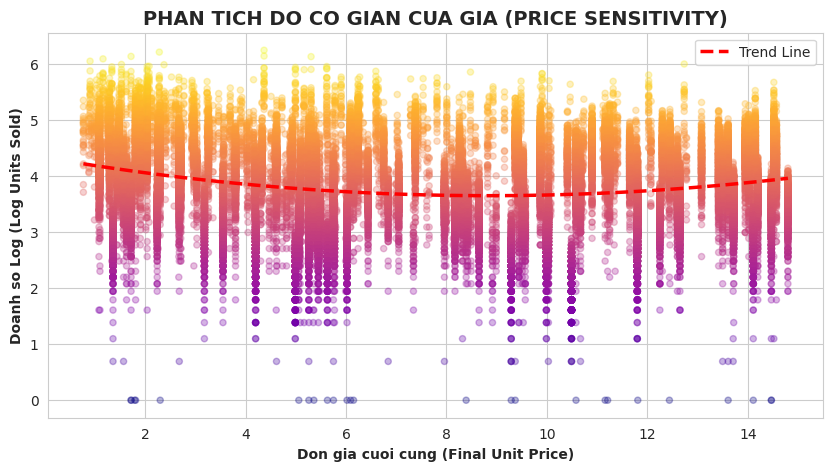

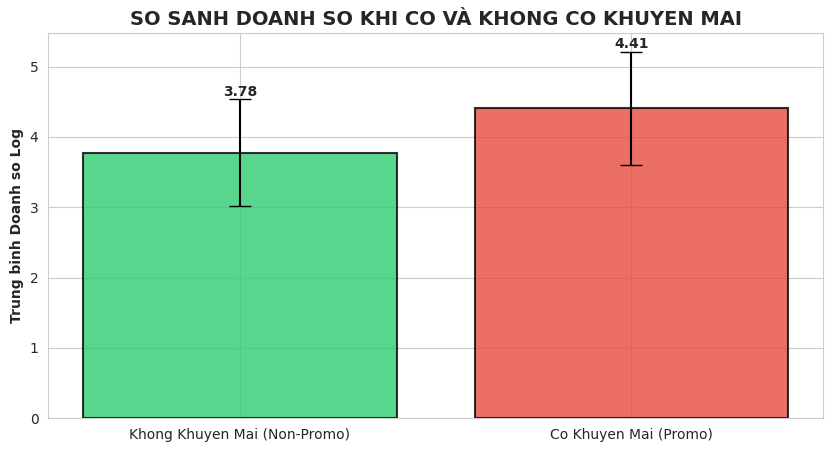

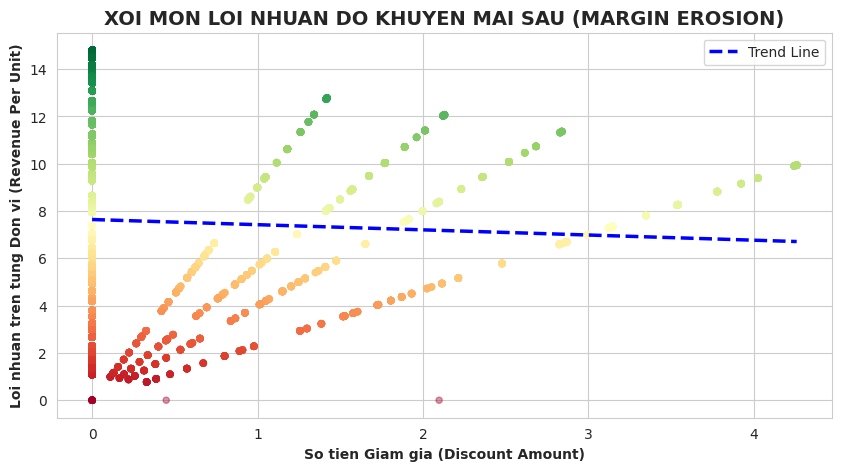

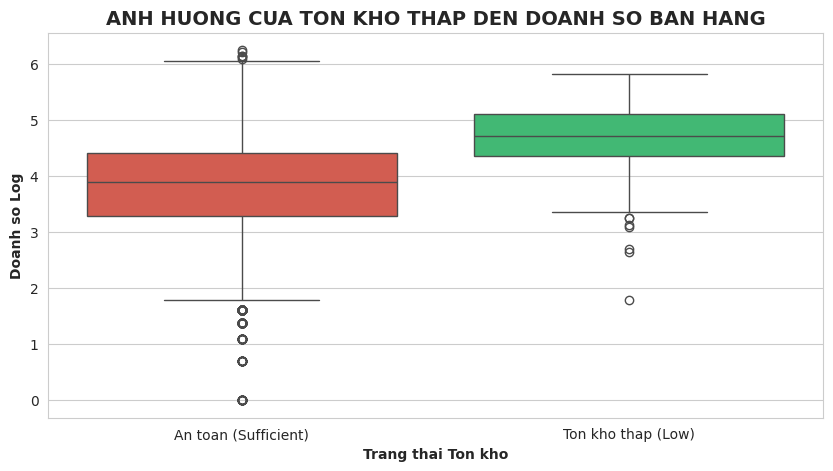

✅ ĐÃ HOÀN TẤT TRỰC QUAN HÓA ĐỂ ĐƯA VÀO BÁO CÁO!


In [ ]:
# =====================================================================
# CELL 8: TRỰC QUAN HÓA PHÂN TÍCH KINH DOANH (PROMO, PRICE, INVENTORY)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("ĐANG CHUYỂN ĐỔI DỮ LIỆU SANG PANDAS ĐỂ VẼ BIỂU ĐỒ...")
# Lấy sample 50,000 dòng để vẽ biểu đồ mượt mà trên Colab không bị sập RAM
df_viz = df_feat.sample(fraction=0.1, seed=42).limit(50000).toPandas()

# Xử lý dữ liệu Pandas
df_viz["date"] = pd.to_datetime(df_viz["date"])
df_viz["is_promo"] = (df_viz["discount_amount"] > 0).astype(int)

# Tạo biến Revenue per unit (Doanh thu trên mỗi đơn vị)
df_viz["revenue_per_unit"] = np.where(df_viz["units_sold"] > 0,
                                      (df_viz["units_sold"] * df_viz["final_unit_price"]) / df_viz["units_sold"], 0)

sns.set_style("whitegrid")

# ---------------------------------------------------------
# BIỂU ĐỒ 1: ĐỘ NHẠY CỦA GIÁ (PRICE SENSITIVITY)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
df_price = df_viz.dropna(subset=["final_unit_price", "log_units_sold"])
plt.scatter(df_price["final_unit_price"], df_price["log_units_sold"],
            alpha=0.3, s=20, c=df_price["log_units_sold"], cmap="plasma")

# Vẽ đường xu hướng (Trend line)
z_price = np.polyfit(df_price["final_unit_price"], df_price["log_units_sold"], 2)
p_price = np.poly1d(z_price)
x_price = np.linspace(df_price["final_unit_price"].min(), df_price["final_unit_price"].max(), 100)
plt.plot(x_price, p_price(x_price), "r--", linewidth=2.5, label="Trend Line")

plt.xlabel("Don gia cuoi cung (Final Unit Price)", fontweight="bold")
plt.ylabel("Doanh so Log (Log Units Sold)", fontweight="bold")
plt.title("PHAN TICH DO CO GIAN CUA GIA (PRICE SENSITIVITY)", fontweight="bold", fontsize=14)
plt.legend()
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ 2: HIỆU QUẢ KHUYẾN MÃI (PROMO UPLIFT)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
uplift_stats = df_viz.groupby("is_promo")["log_units_sold"].agg(["mean", "std"]).reset_index()
uplift_stats["promo_label"] = uplift_stats["is_promo"].map({0: "Khong Khuyen Mai (Non-Promo)", 1: "Co Khuyen Mai (Promo)"})

plt.bar(uplift_stats["promo_label"], uplift_stats["mean"], yerr=uplift_stats["std"],
        capsize=8, color=["#2ecc71", "#e74c3c"], alpha=0.8, edgecolor="black", linewidth=1.5)

plt.ylabel("Trung binh Doanh so Log", fontweight="bold")
plt.title("SO SANH DOANH SO KHI CO VÀ KHONG CO KHUYEN MAI", fontweight="bold", fontsize=14)
for i, (v, std) in enumerate(zip(uplift_stats["mean"], uplift_stats["std"])):
    plt.text(i, v + std + 0.05, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ 3: XÓI MÒN LỢI NHUẬN (MARGIN EROSION)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
df_margin = df_viz.dropna(subset=["discount_amount", "revenue_per_unit"])
plt.scatter(df_margin["discount_amount"], df_margin["revenue_per_unit"],
            alpha=0.4, s=20, c=df_margin["revenue_per_unit"], cmap="RdYlGn")

z_margin = np.polyfit(df_margin["discount_amount"], df_margin["revenue_per_unit"], 1)
p_margin = np.poly1d(z_margin)
x_margin = np.linspace(df_margin["discount_amount"].min(), df_margin["discount_amount"].max(), 100)
plt.plot(x_margin, p_margin(x_margin), "b--", linewidth=2.5, label="Trend Line")

plt.xlabel("So tien Giam gia (Discount Amount)", fontweight="bold")
plt.ylabel("Loi nhuan tren tung Don vi (Revenue Per Unit)", fontweight="bold")
plt.title("XOI MON LOI NHUAN DO KHUYEN MAI SAU (MARGIN EROSION)", fontweight="bold", fontsize=14)
plt.legend()
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ 4: RÀNG BUỘC TỒN KHO & DOANH SỐ (INVENTORY CONSTRAINT)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
df_stock = df_viz.dropna(subset=["inventory_to_sales_ratio", "log_units_sold"])
df_stock["low_stock_flag"] = np.where(df_stock["inventory_to_sales_ratio"] < 1, "Ton kho thap (Low)", "An toan (Sufficient)")

sns.boxplot(data=df_stock, x="low_stock_flag", y="log_units_sold", palette=["#e74c3c", "#2ecc71"])
plt.xlabel("Trang thai Ton kho", fontweight="bold")
plt.ylabel("Doanh so Log", fontweight="bold")
plt.title("ANH HUONG CUA TON KHO THAP DEN DOANH SO BAN HANG", fontweight="bold", fontsize=14)
plt.show()

print("✅ ĐÃ HOÀN TẤT TRỰC QUAN HÓA ĐỂ ĐƯA VÀO BÁO CÁO!")

# Visualization & Business Report

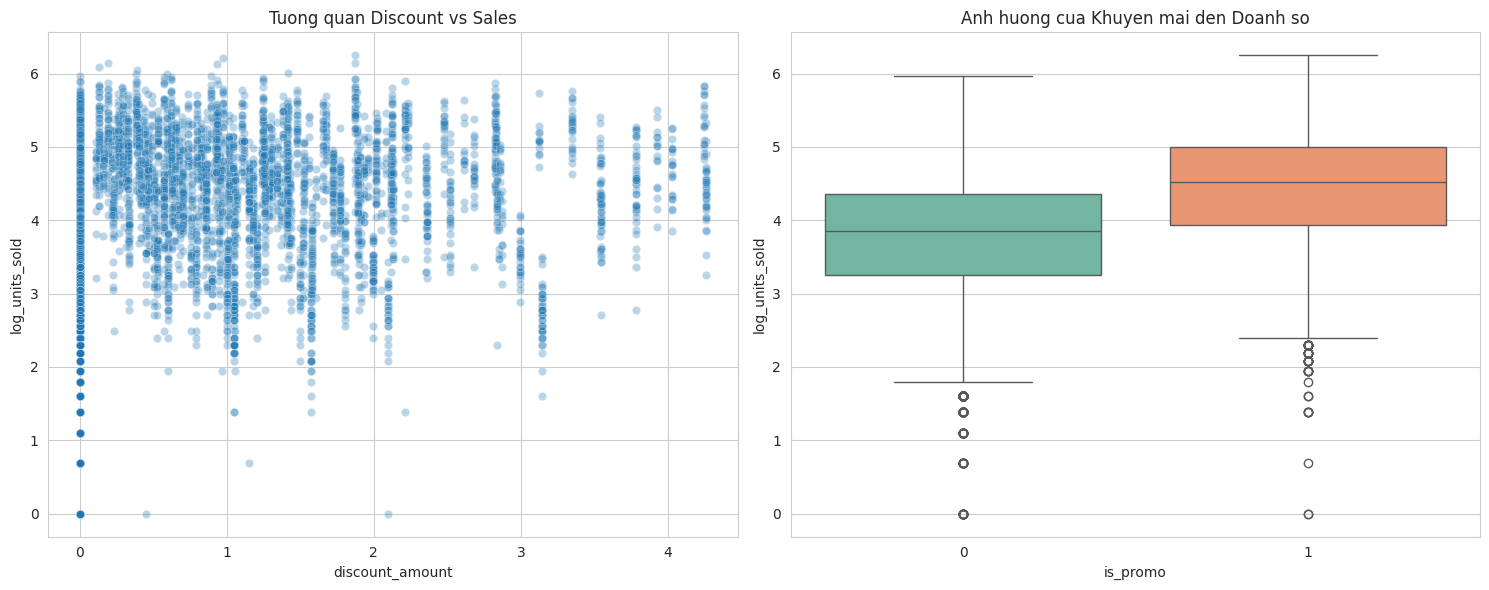

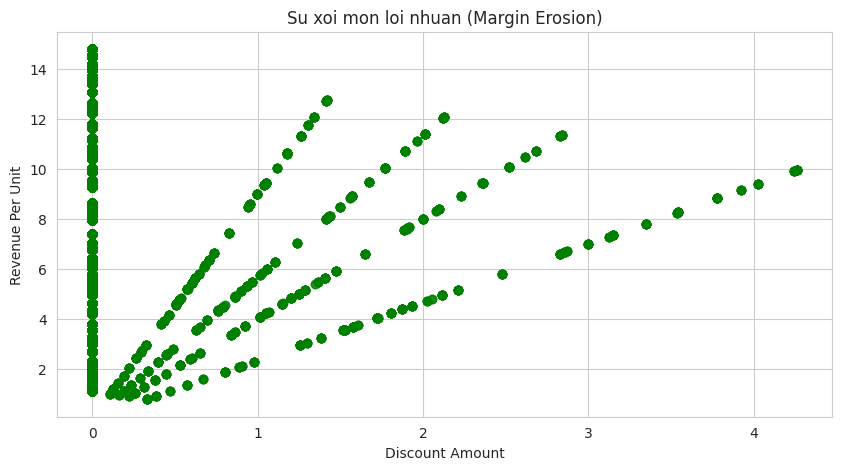

In [ ]:
# =====================================================================
# CELL 9: VISUALIZATION & BUSINESS REPORT
# =====================================================================
# Lưu ý: Chúng ta dùng trực tiếp df_viz đã có sẵn từ Cell 8 trước đó
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cấu hình phong cách
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # Dùng font mặc định của Colab

def generate_business_report(df):
    # Tạo các cột phụ trợ cần thiết cho đồ thị
    df['is_promo'] = (df['discount_amount'] > 0).astype(int)

    # 1. Vẽ biểu đồ: ĐỘ CẢM BIẾN GIÁ & KHUYẾN MÃI (Gộp ý tưởng từ code PART 2)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Biểu đồ 1: Tương quan Discount Amount vs Sales
    sns.scatterplot(data=df, x='discount_amount', y='log_units_sold', ax=axes[0], alpha=0.3)
    axes[0].set_title('Tuong quan Discount vs Sales')

    # Biểu đồ 2: Khuyến mãi vs Doanh số
    sns.boxplot(data=df, x='is_promo', y='log_units_sold', ax=axes[1], palette="Set2")
    axes[1].set_title('Anh huong cua Khuyen mai den Doanh so')

    plt.tight_layout()
    plt.show()

    # 2. Phân tích lợi nhuận: Margin Erosion
    plt.figure(figsize=(10, 5))
    # Loại bỏ giá trị âm để vẽ log
    df_margin = df[df['revenue_per_unit'] > 0]
    plt.scatter(df_margin['discount_amount'], df_margin['revenue_per_unit'], alpha=0.3, c='green')
    plt.title('Su xoi mon loi nhuan (Margin Erosion)')
    plt.xlabel('Discount Amount')
    plt.ylabel('Revenue Per Unit')
    plt.show()

# Gọi hàm với dữ liệu đã chuẩn bị
generate_business_report(df_viz)